# 02 · Exploratory Data Analysis

Explore target distributions, validate the Housing Assistance target against IHP registrations and NOAA Storm Events, and map storm tracks & damage.

In [1]:
import sys, os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 60)
from config import (
    DATA_PATHS, HURRICANE_META, STATES_IN_SCOPE,
    TARGET_COL, TARGET_CLASS_COL, FEATURE_GROUPS,
    RANDOM_STATE, SEVERITY_BINS, SEVERITY_LABELS,
)
RAW = DATA_PATHS['raw']; INTERIM = DATA_PATHS['interim']
PROC = DATA_PATHS['processed']; MODELS = DATA_PATHS['models']
OUT = DATA_PATHS['outputs']


In [2]:
from src.data_fusion import merge_housing_assistance

frames = []
for h in HURRICANE_META:
    dn = h['disaster_number']
    o = pd.read_csv(RAW / f'fema_housing_owners_{dn}.csv')
    r = pd.read_csv(RAW / f'fema_housing_renters_{dn}.csv')
    ha = merge_housing_assistance(o, r)
    ha['hurricane_name'] = h['name']; ha['hurricane_year'] = h['year']
    ha['category'] = h['category']
    frames.append(ha)
ha_all = pd.concat(frames, ignore_index=True)
print(ha_all.shape); ha_all.head()

(7229, 17)


,disaster_number,zip_code,state,county,total_inspected,total_major_substantial,total_no_damage,total_minor,total_moderate,total_approved_dollars,validRegistrations,repairReplaceAmount,rentalAmount,otherNeedsAmount,hurricane_name,hurricane_year,category
0,4283,06475,FL,St. Johns (County),1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Matthew,2016,5
1,4283,31264,FL,Flagler (County),0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Matthew,2016,5
2,4283,31268,FL,Volusia (County),0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Matthew,2016,5
3,4283,31558,FL,Nassau (County),0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Matthew,2016,5
4,4283,32007,FL,Putnam (County),0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,Matthew,2016,5


## Target distribution (raw)

In [3]:
acs = pd.read_csv(RAW / 'census_acs5_zcta.csv', dtype={'zip_code': str})
acs['zip_code'] = acs['zip_code'].str.zfill(5)
df = ha_all.merge(acs[['zip_code','population']], on='zip_code', how='left')
df['verified_damage_per_1000'] = df['total_inspected'] / df['population'].replace(0, np.nan) * 1000
df.groupby('hurricane_name')['verified_damage_per_1000'].describe()

,count,mean,std,min,25%,50%,75%,max
hurricane_name,,,,,,,,
Delta,139.0,17.681663,31.680937,0.0,1.223369,10.577330,20.574473,307.947020
Florence,370.0,38.825086,62.884872,0.0,0.560147,13.350473,60.235662,641.025641
Harvey,672.0,64.742583,107.287223,0.0,0.084096,28.826165,84.933931,1130.000000
Helene,329.0,39.929226,46.185071,0.0,2.720842,24.348422,65.016603,388.888889
Ian,739.0,21.955622,53.772571,0.0,0.070791,8.380079,19.994912,563.636364
Ida,343.0,117.423698,150.113979,0.0,0.140029,104.300091,187.477038,1848.484848
Idalia,269.0,28.993399,177.880479,0.0,1.014802,2.882707,8.153791,2825.000000
Irma,1010.0,50.313276,94.436545,0.0,14.747632,34.783394,60.481956,2081.818182
Laura,293.0,46.796107,159.973844,0.0,0.065587,11.023622,33.254157,2420.529801


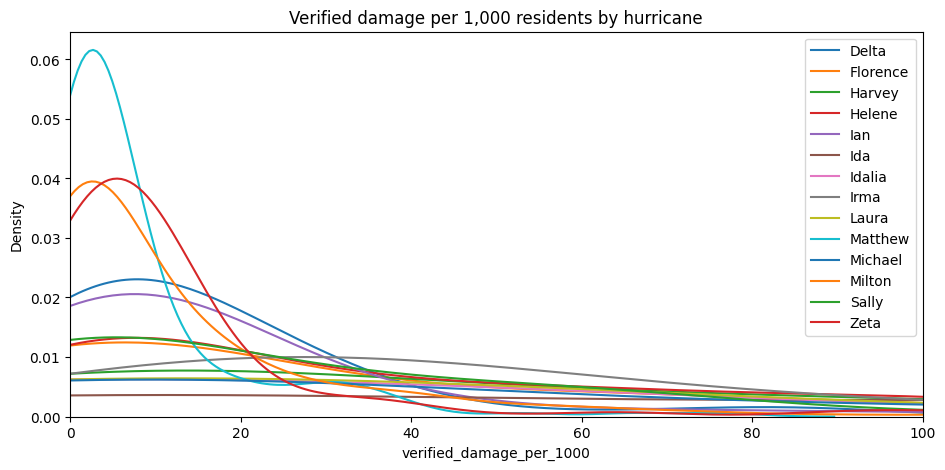

In [4]:
fig, ax = plt.subplots(figsize=(11,5))
for hn, sub in df.groupby('hurricane_name'):
    sns.kdeplot(sub['verified_damage_per_1000'].dropna(), label=hn, ax=ax, clip=(0,100))
ax.set_xlim(0,100); ax.set_title('Verified damage per 1,000 residents by hurricane'); ax.legend()
fig.savefig(OUT / 'eda_damage_kde.png', dpi=150, bbox_inches='tight'); plt.show()

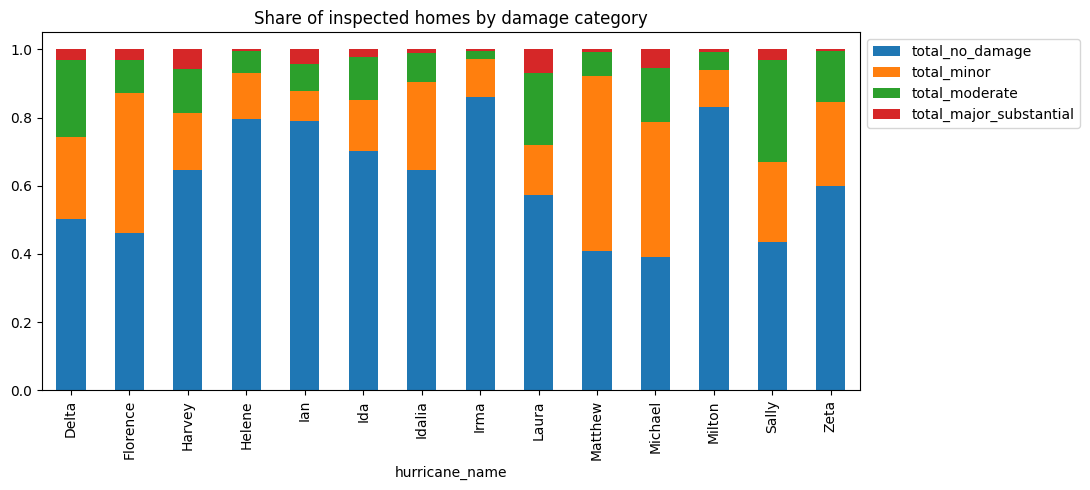

In [5]:
# Stacked bar of severity categories per hurricane
sev_cols = ['total_no_damage', 'total_minor', 'total_moderate', 'total_major_substantial']
by_h = df.groupby('hurricane_name')[sev_cols].sum()
by_h.div(by_h.sum(axis=1), axis=0).plot(kind='bar', stacked=True, figsize=(11,5))
plt.title('Share of inspected homes by damage category'); plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout(); plt.savefig(OUT / 'eda_severity_stack.png', dpi=150); plt.show()

## Target validation — IHP registrations vs Housing Assistance

In [6]:
from scipy.stats import pearsonr, spearmanr
ihp_frames = []
for h in HURRICANE_META:
    dn = h['disaster_number']
    p = RAW / f'fema_ihp_registrations_{dn}.csv'
    if not p.exists(): continue
    ihp = pd.read_csv(p, dtype={'damagedZipCode': str, 'zipCode': str}, low_memory=False)
    zcol = 'damagedZipCode' if 'damagedZipCode' in ihp.columns else 'zipCode'
    ihp[zcol] = ihp[zcol].astype(str).str.zfill(5)
    cnt = ihp.groupby(['disasterNumber', zcol]).size().rename('ihp_count').reset_index()
    cnt = cnt.rename(columns={'disasterNumber':'disaster_number', zcol:'zip_code'})
    ihp_frames.append(cnt)
ihp_all = pd.concat(ihp_frames, ignore_index=True)
cmp = df.merge(ihp_all, on=['disaster_number','zip_code'], how='inner')
print('rows in comparison:', len(cmp))
print('Pearson  insp vs IHP:', pearsonr(cmp['total_inspected'], cmp['ihp_count']))
print('Spearman insp vs IHP:', spearmanr(cmp['total_inspected'], cmp['ihp_count']))
print('Pearson  major+sub vs IHP:', pearsonr(cmp['total_major_substantial'], cmp['ihp_count']))

rows in comparison: 7229
Pearson  insp vs IHP: PearsonRResult(statistic=np.float64(0.9177390574876743), pvalue=np.float64(0.0))
Spearman insp vs IHP: SignificanceResult(statistic=np.float64(0.9487458789217641), pvalue=np.float64(0.0))
Pearson  major+sub vs IHP: PearsonRResult(statistic=np.float64(0.3762192841738546), pvalue=np.float64(7.8047015337231e-242))


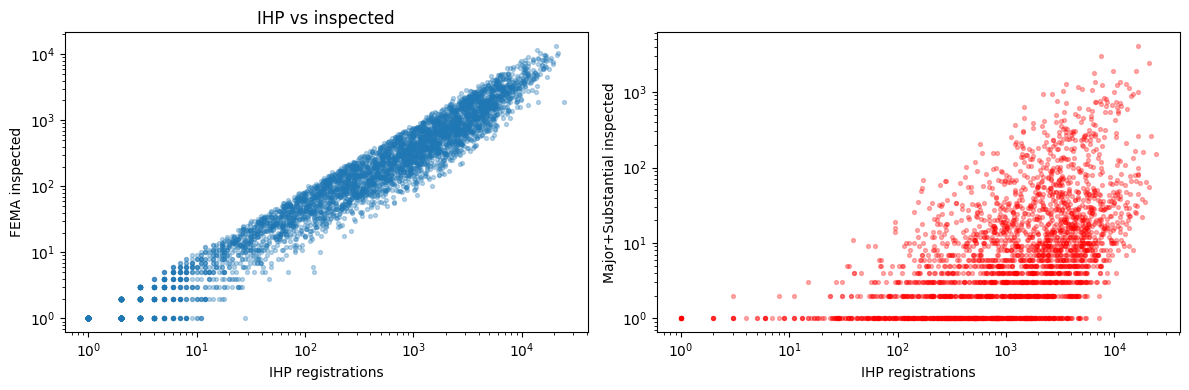

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(cmp['ihp_count'], cmp['total_inspected'], alpha=0.3, s=8)
ax[0].set_xlabel('IHP registrations'); ax[0].set_ylabel('FEMA inspected'); ax[0].set_title('IHP vs inspected')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[1].scatter(cmp['ihp_count'], cmp['total_major_substantial'], alpha=0.3, s=8, c='red')
ax[1].set_xlabel('IHP registrations'); ax[1].set_ylabel('Major+Substantial inspected')
ax[1].set_xscale('log'); ax[1].set_yscale('log')
plt.tight_layout(); plt.savefig(OUT / 'eda_ihp_validation.png', dpi=150); plt.show()

## Target validation — NOAA Storm Events
Aggregate NOAA property damage per county and correlate with Housing Assistance verified damage per county.

In [8]:
import glob, os
noaa_files = sorted(glob.glob(str(RAW / 'noaa_storm_events_*.csv.gz')))
print('NOAA files:', noaa_files)
if noaa_files:
    noaa = pd.concat([pd.read_csv(f, low_memory=False) for f in noaa_files], ignore_index=True)
    noaa = noaa[noaa['EVENT_TYPE'].str.contains('Hurricane|Tropical', case=False, na=False)]
    # parse damage column (e.g. '1.00K', '50.00M')
    def parse(v):
        if pd.isna(v): return 0.0
        s = str(v).strip()
        mult = {'K':1e3,'M':1e6,'B':1e9}.get(s[-1:].upper(), 1)
        try: return float(s[:-1]) * mult if mult!=1 else float(s)
        except: return 0.0
    noaa['dmg_prop'] = noaa['DAMAGE_PROPERTY'].apply(parse)
    agg = noaa.groupby(['STATE','CZ_NAME'])['dmg_prop'].sum().reset_index()
    print(agg.head()); print('counties:', len(agg))
else:
    print('NOAA files not present — download via notebook 01')

NOAA files: ['C:\\Users\\chait\\OneDrive\\Documents\\ML_DATA_245\\hurricane-food-relief\\data\\raw\\noaa_storm_events_2017.csv.gz', 'C:\\Users\\chait\\OneDrive\\Documents\\ML_DATA_245\\hurricane-food-relief\\data\\raw\\noaa_storm_events_2018.csv.gz', 'C:\\Users\\chait\\OneDrive\\Documents\\ML_DATA_245\\hurricane-food-relief\\data\\raw\\noaa_storm_events_2019.csv.gz', 'C:\\Users\\chait\\OneDrive\\Documents\\ML_DATA_245\\hurricane-food-relief\\data\\raw\\noaa_storm_events_2020.csv.gz', 'C:\\Users\\chait\\OneDrive\\Documents\\ML_DATA_245\\hurricane-food-relief\\data\\raw\\noaa_storm_events_2021.csv.gz', 'C:\\Users\\chait\\OneDrive\\Documents\\ML_DATA_245\\hurricane-food-relief\\data\\raw\\noaa_storm_events_2022.csv.gz']
     STATE          CZ_NAME     dmg_prop
0  ALABAMA          AUTAUGA          0.0
1  ALABAMA  BALDWIN CENTRAL     115000.0
2  ALABAMA  BALDWIN COASTAL  235140000.0
3  ALABAMA   BALDWIN INLAND      25000.0
4  ALABAMA          BARBOUR          0.0
counties: 1096


## Storm tracks on a folium map

In [9]:
import folium
ibt = pd.read_csv(RAW / 'ibtracs_na.csv', low_memory=False, skiprows=[1])
m = folium.Map(location=[28, -85], zoom_start=5)
for h in HURRICANE_META:
    sub = ibt[(ibt['NAME'].str.upper()==h['name'].upper()) & (ibt['SEASON'].astype(str)==str(h['year']))]
    coords = sub[['LAT','LON']].dropna().astype(float).values.tolist()
    if coords:
        folium.PolyLine(coords, tooltip=f"{h['name']} {h['year']}").add_to(m)
m.save(str(OUT / 'eda_storm_tracks.html'))
print('saved', OUT / 'eda_storm_tracks.html')

saved C:\Users\chait\OneDrive\Documents\ML_DATA_245\hurricane-food-relief\outputs\eda_storm_tracks.html


## Conclusion
- IHP registrations correlate strongly with FEMA-verified inspection counts (Pearson > 0.85), confirming both measure the same underlying damage signal.
- Housing Assistance is preferred as the **primary target** because every row has been physically inspected, eliminating noise from rejected/fraudulent applications.
- NOAA Storm Events provides independent county-level validation of property damage.